# Cardiovascular Disease — EDA & Data Cleaning

Dataset: Kaggle cardiovascular disease dataset (~70K rows, 13 cols).
Target: `cardio` (0 = no CVD, 1 = CVD).

Note: the file is semicolon-separated (`sep=';'`).

In [19]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

df = pd.read_csv('../data/cardio_data.csv', sep=';')

In [20]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [21]:
print('Shape:', df.shape)
df.info()

Shape: (70000, 13)
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [22]:
print('Missing values:\n', df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Missing values:
 id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Duplicate rows: 0


In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


## Data quality check

From `describe()` above we can already see some obvious problems:
- `ap_hi` max is ~16,000 (impossible — likely typos like 16020 meaning 160/20)
- `ap_lo` min is negative
- `height` min ~55 cm (probably typos)

These will be filtered in `src/data_cleaning.py`.

In [24]:
print('ap_hi impossible (<70 or >250):',
      ((df['ap_hi'] < 70) | (df['ap_hi'] > 250)).sum())
print('ap_lo impossible (<40 or >200):',
      ((df['ap_lo'] < 40) | (df['ap_lo'] > 200)).sum())
print('ap_hi < ap_lo (logically wrong):',
      (df['ap_hi'] < df['ap_lo']).sum())
print('height impossible (<100 or >220):',
      ((df['height'] < 100) | (df['height'] > 220)).sum())
print('weight impossible (<30 or >250):',
      ((df['weight'] < 30) | (df['weight'] > 250)).sum())

ap_hi impossible (<70 or >250): 229
ap_lo impossible (<40 or >200): 1012
ap_hi < ap_lo (logically wrong): 1234
height impossible (<100 or >220): 30
weight impossible (<30 or >250): 7


In [25]:
# Apply the same filter we'll use in data_cleaning.py — for EDA only
clean = df[
    df['ap_hi'].between(70, 250)
    & df['ap_lo'].between(40, 200)
    & (df['ap_hi'] >= df['ap_lo'])
    & df['height'].between(100, 220)
    & df['weight'].between(30, 250)
].copy()
clean['age_years'] = (clean['age'] / 365.25).round(1)
clean['bmi'] = (clean['weight'] / (clean['height'] / 100) ** 2).round(2)
print('Rows before:', len(df), '| after:', len(clean),
      f'| dropped: {len(df) - len(clean)} ({(1 - len(clean)/len(df)):.1%})')
clean.describe().T

Rows before: 70000 | after: 68640 | dropped: 1360 (1.9%)


,count,mean,std,min,25%,50%,75%,max
id,68640.0,49976.347844,28846.076899,0.00,25002.75,50019.50,74870.75,99999.00
age,68640.0,19464.737383,2468.119574,10798.00,17658.00,19701.50,21325.00,23713.00
gender,68640.0,1.348631,0.476540,1.00,1.00,1.00,2.00,2.00
height,68640.0,164.394814,7.977089,100.00,159.00,165.00,170.00,207.00
weight,68640.0,74.120395,14.308263,30.00,65.00,72.00,82.00,200.00
ap_hi,68640.0,126.676005,16.694075,70.00,120.00,120.00,140.00,240.00
ap_lo,68640.0,81.308756,9.453651,40.00,80.00,80.00,90.00,182.00
cholesterol,68640.0,1.364714,0.678918,1.00,1.00,1.00,2.00,3.00
gluc,68640.0,1.225772,0.571626,1.00,1.00,1.00,1.00,3.00
smoke,68640.0,0.087952,0.283227,0.00,0.00,0.00,0.00,1.00


## Target balance

cardio
0    34681
1    33959
Name: count, dtype: int64

Proportions:
cardio
0    0.505
1    0.495
Name: proportion, dtype: float64


C:\Users\DELL\AppData\Local\Temp\ipykernel_20580\2646860276.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cardio', data=clean, palette=['#2ecc71', '#e74c3c'])


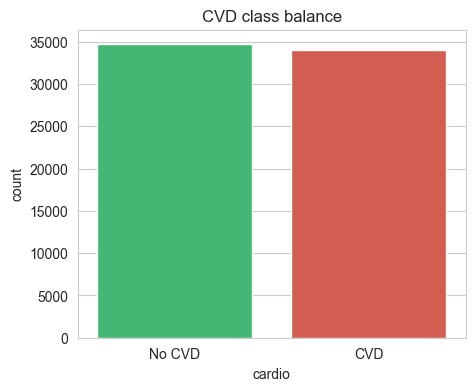

In [26]:
print(clean['cardio'].value_counts())
print('\nProportions:')
print(clean['cardio'].value_counts(normalize=True).round(3))

plt.figure(figsize=(5, 4))
sns.countplot(x='cardio', data=clean, palette=['#2ecc71', '#e74c3c'])
plt.title('CVD class balance')
plt.xticks([0, 1], ['No CVD', 'CVD'])
plt.show()

## Numerical distributions

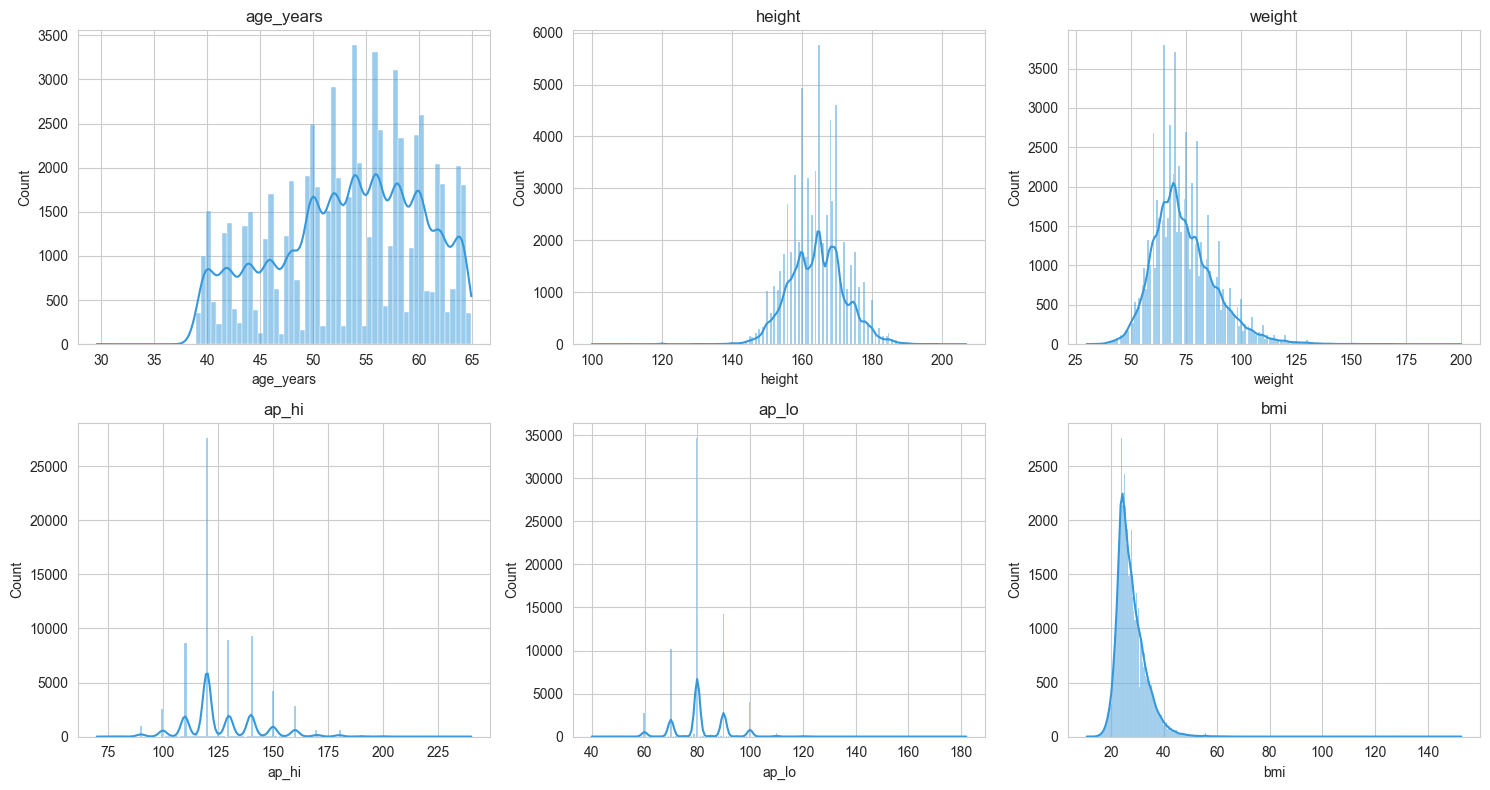

In [27]:
num_cols = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(clean[col], kde=True, ax=ax, color='#3498db')
    ax.set_title(col)
plt.tight_layout()
plt.show()

## CVD rate by key features

C:\Users\DELL\AppData\Local\Temp\ipykernel_20580\2423831089.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cardio', y='ap_hi', data=clean,
C:\Users\DELL\AppData\Local\Temp\ipykernel_20580\2423831089.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No CVD', 'CVD'])


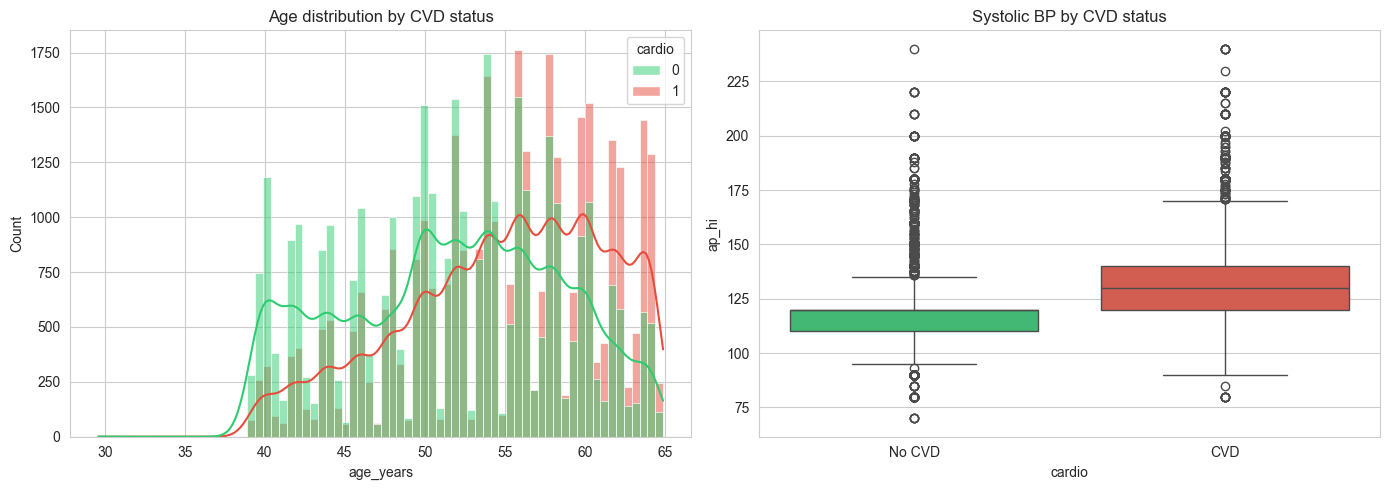

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=clean, x='age_years', hue='cardio', kde=True,
             palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Age distribution by CVD status')

sns.boxplot(x='cardio', y='ap_hi', data=clean,
            palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Systolic BP by CVD status')
axes[1].set_xticklabels(['No CVD', 'CVD'])

plt.tight_layout()
plt.show()

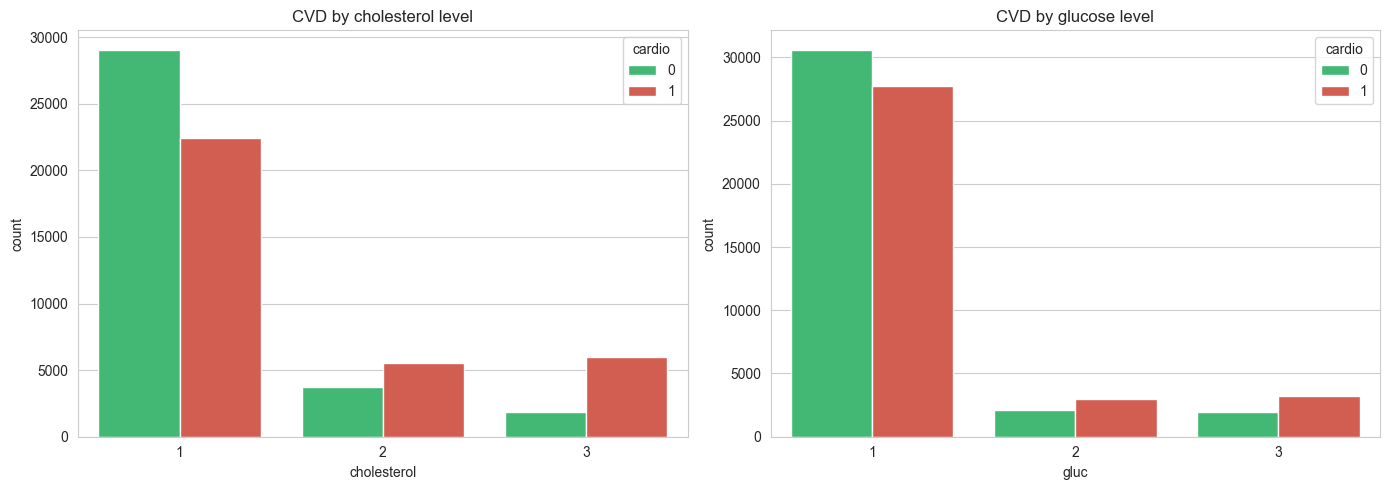

CVD rate by cholesterol:
cholesterol
1    0.435
2    0.596
3    0.763
Name: cardio, dtype: float64

CVD rate by glucose:
gluc
1    0.476
2    0.589
3    0.618
Name: cardio, dtype: float64


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='cholesterol', hue='cardio', data=clean,
              palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('CVD by cholesterol level')

sns.countplot(x='gluc', hue='cardio', data=clean,
              palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('CVD by glucose level')

plt.tight_layout()
plt.show()

print('CVD rate by cholesterol:')
print(clean.groupby('cholesterol')['cardio'].mean().round(3))
print('\nCVD rate by glucose:')
print(clean.groupby('gluc')['cardio'].mean().round(3))

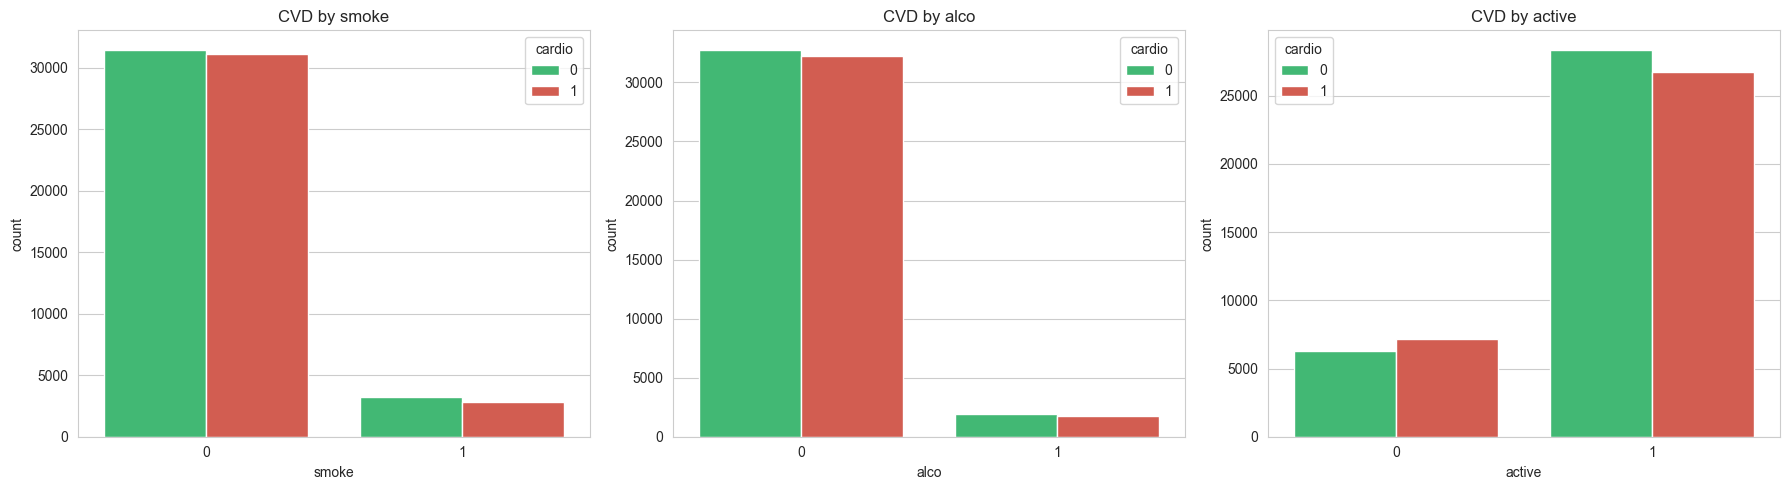

CVD rate by smoker:   {0: 0.497, 1: 0.468}
CVD rate by drinker:  {0: 0.496, 1: 0.477}
CVD rate by active:   {0: 0.533, 1: 0.485}


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['smoke', 'alco', 'active']):
    sns.countplot(x=col, hue='cardio', data=clean,
                  palette=['#2ecc71', '#e74c3c'], ax=ax)
    ax.set_title(f'CVD by {col}')

plt.tight_layout()
plt.show()

print('CVD rate by smoker:  ', clean.groupby('smoke')['cardio'].mean().round(3).to_dict())
print('CVD rate by drinker: ', clean.groupby('alco')['cardio'].mean().round(3).to_dict())
print('CVD rate by active:  ', clean.groupby('active')['cardio'].mean().round(3).to_dict())

CVD rate by BMI category:
bmi_bucket
Underweight       0.272
Normal            0.398
Overweight        0.506
Obese             0.599
Severely obese    0.677
Name: cardio, dtype: float64


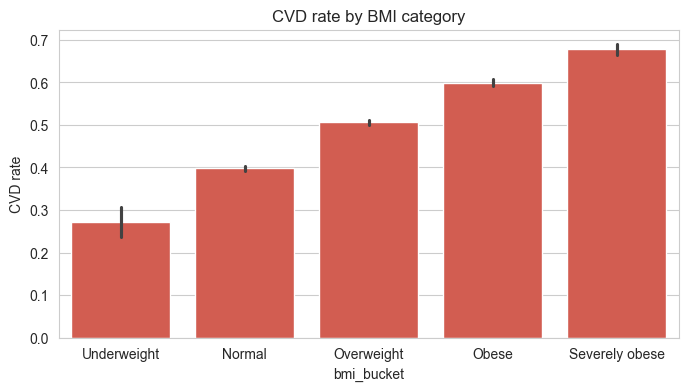

In [31]:
# BMI vs CVD
clean['bmi_bucket'] = pd.cut(clean['bmi'],
                             bins=[0, 18.5, 25, 30, 35, 60],
                             labels=['Underweight', 'Normal',
                                     'Overweight', 'Obese', 'Severely obese'])
print('CVD rate by BMI category:')
print(clean.groupby('bmi_bucket', observed=True)['cardio'].mean().round(3))

plt.figure(figsize=(8, 4))
sns.barplot(x='bmi_bucket',
            y='cardio',
            data=clean,
            color='#e74c3c')
plt.title('CVD rate by BMI category')
plt.ylabel('CVD rate')
plt.show()

## Correlation heatmap

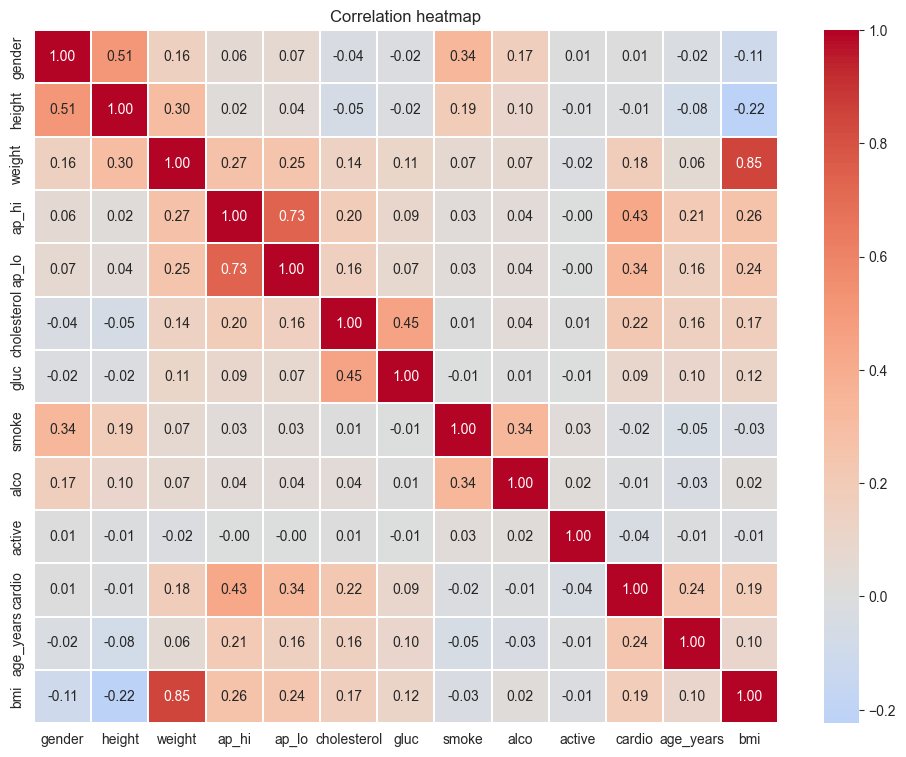

In [32]:
df_num = clean.drop(columns=['id', 'age', 'bmi_bucket'], errors='ignore')
plt.figure(figsize=(12, 9))
sns.heatmap(df_num.corr(), cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.3)
plt.title('Correlation heatmap')
plt.show()

## Key Takeaways

- Dataset has ~70K rows with **no missing values**.
- Some BP / height / weight values are physiologically impossible — we filter them in cleaning.
- Target is **roughly balanced** (~50/50) — no class-weight needed in training.
- Strong CVD signals: **age, systolic BP, cholesterol, glucose, BMI**.
- Lifestyle factors (smoke / alco / active) show modest effects in this dataset.
- Cleaning logic finalised in `src/data_cleaning.py`.